#**PROCESAMIENTO DE SEÑALES CARDIOVASCULARES**#

Procesamiento básico de series temporales de latidos cardiovasculares tales como la presión, el diámetro o el flujo arteriales.

**ACCIONES BÁSICAS**:

1.   Acondicionamiento (eliminación de ruido)
2.   Detección de latidos
3.   Determinación del Latido Promedio

## **MÓDULOS DE USO GENERAL**

In [1]:
import numpy as np              #Módulo Numérico General
import scipy as sp              #Módulo Procesamiento de Señales
import math as mt               #Módulo Matemático
import matplotlib.pyplot as plt #Visualización

## **FUNCIONES DE USO ESPECÍFICO**

In [2]:
def FUN_DetLatidos(x, P_Umbral, TipoDet):
#--------------------------------------------------------------------------
#FUNCION:FUN_DetLatidos
#Detección de latidos en la señal de análisis aplicando:
#                        1) max(dx/dt) (Derivada)
#                        2) Maximos
#                        3) Minimos
#                        4) Pie de onda
#
#ENTRADA: x           -> Señal a analizar
#         P_Umbral    -> Porcentaje del máximo (por arriba de este) a
#                        partir del cual no se consideran los máximos/minimos
#                        relativos
#         TipoDet     -> Tipo de cálculo de períodos (1,2,3,4)
#SALIDA:  x_Latidos   -> Marcas de los latidos (máximos) en un vector de long x
#
#EJEMPLO:
#    x_Latidos=FUN_DetLatidos(x, 90, 1)
#    plt.plot(t,x,t,x_latidos)
#
#MÓDULOS UTILIZADOS:
#    numpy (as np) y scipy (as sp)
#--------------------------------------------------------------------------
    # Pasaje de P_Umbral (está en %)
    P_Umbral = P_Umbral / 100
    # Valor máximo para marca de ciclos
    x_Max = np.max(x)
    # Filtrado de media móvil pasabajos para eliminación de ruido
    x = sp.signal.filtfilt(np.ones(5) / 5, 1, x)
    # Almacenamiento de los períodos (marca en su ubicación)
    x_Latidos = np.zeros(len(x))
    if TipoDet == 1:  # Derivada máxima
        # Cálculo de la derivada
        x_DER = np.gradient(x)
        # Umbral de cálculo de los máximos
        x_Umbral = P_Umbral * np.max(x_DER)
        # Eliminación de los valores mayores al umbral
        x_DER = x_DER * (x_DER > x_Umbral)
        for k in range(1, len(x) - 1):
            if x_DER[k] >= x_DER[k + 1] and x_DER[k] > x_DER[k - 1] and x[k] > 0:
                x_Latidos[k] = x_Max
    elif TipoDet == 2:  # Máximos
        # Umbral de cálculo de los máximos
        x_Umbral = P_Umbral * np.max(x)
        # Eliminación de los valores mayores al umbral
        Sen = x * (x > x_Umbral)
        for k in range(1, len(x) - 1):
            if Sen[k] >= x[k + 1] and x[k] > x[k - 1] and x[k] > 0:
                x_Latidos[k] = x_Max
    elif TipoDet == 3:  # Mínimos
        # Umbral de cálculo de los mínimos
        x_Umbral = (1 + P_Umbral) * np.min(x)
        # Eliminación de los valores menores al umbral
        x = x * (x < x_Umbral)
        for k in range(1, len(x) - 1):
            if x[k] <= x[k + 1] and x[k] < x[k - 1] and x[k] < 0:
                x_Latidos[k] = x_Max
    elif TipoDet == 4: #Pie de onda
        # Cálculo de la derivada
        x_DER = np.gradient(x)
        # Umbral de cálculo de los máximos
        x_Umbral = P_Umbral * np.max(x_DER)
        # Eliminación de los valores mayores al umbral
        x_DER = x_DER * (x_DER > x_Umbral)
        x_Latidos = np.zeros_like(x)
        for k in range(1, len(x) - 1):
            if x_DER[k] >= x_DER[k + 1] and x_DER[k] > x_DER[k - 1] and x[k] > 0:
            # Si encuentra un máximo de derivada, busca hacia atrás en la señal
            # punto a punto el pie de onda (hasta que x[k] < x[k - 1])
               for m in range(1, k - 1):
                   # Búsqueda hacia atrás del pie de onda
                   if x[k - m] < x[k - m - 1]:
                      x_Latidos[k - m] = x_Max
                      break
    return x_Latidos

def FUN_PromLatidos(x, x_PosLat, t):
#--------------------------------------------------------------------------
#FUNCION:FUN_PromLat
#Cálculo de un latido promedio correspondiente a los latidos detectados de una serie.
#Los latidos se interpolan previamente a un un latido cuya duración es la mínima de las
#duraciones de todos los latidos, para evitar deformación por diferencia de duración.
#
#ENTRADA: x          -> Señal a analizar
#         x_PosLat   -> Ubicación de los latidos (se obtiene con FUN_DetLatidos)
#         t          -> Intervalo temporal
#SALIDA:  Lat_Prom   -> Latido promediado a la duración de latido mínima
#         t_prom     -> Vector temporal latido promedio
#
#EJEMPLO:
#    x_Latidos=FUN_DetCiclos(x, 90, 1)
#    x_PosLat = np.where(x_latidos)[0]
#    Lat_Prom,t_Prom=FUN_PromLatidos(xf_BT_ff, x_PosLat, t)
#
#MÓDULOS UTILIZADOS:
#    numpy (as np) y scipy (as sp)
#--------------------------------------------------------------------------
    #Intervalo de muestreo
    Ts = t[1] - t[0]
    #Vector Latido Promedio
    Lat_Prom = 0
    #Latido de duración mínima
    Lat_Long_min = min(np.diff(x_PosLat))
    for k in range(len(x_PosLat)-1):
        #Intervalo latido a interpolar (definido de 0 a 1)
        pini = x_PosLat[k]
        pfin = x_PosLat[k+1] - 1
        Lat_t_act=np.linspace(0,1,pfin-pini)
        #Intervalo latido interpolado (definido de 0 a 1)
        Lat_t_min=np.linspace(0,1,Lat_Long_min)
        #Interpolación latido
        Lat_int = np.interp(Lat_t_min, Lat_t_act, x[pini:pfin])
        #Suma de latido interpolado
        Lat_Prom += Lat_int
    #Promedio según la cantidad de latidos
    Lat_Prom /= len(x_PosLat) - 1
    t_Prom=np.arange(0,Lat_Long_min*Ts,Ts)
    return Lat_Prom, t_Prom

## **CARGA DE SEÑALES PARA EVALUACIÓN**

Text(0, 0.5, 'Amplitud')

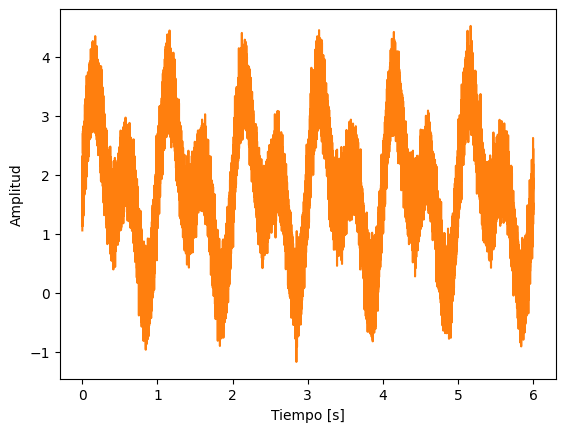

In [3]:
#EJEMPLO: SIMULACIÓN SEÑAL CONTAMINADA CON RUIDO BLANCO GAUSSIANO
Ts=0.0001
Fs=1/Ts
N_Ciclos=6 #Ciclos de 1s
t=np.arange(0,N_Ciclos,Ts)
x=np.sin(2*np.pi*t)+np.sin(4*np.pi*t)
x=x+np.abs(np.min(x))
wgn=np.random.normal(0, 0.3, size=len(t))
x_wgn=x+wgn

#Visualización
plt.plot(t,x,t,x_wgn)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')

## **PROCESAMIENTO INICIAL**

### **1. ANÁLISIS ESPECTRAL Y ACONDICIONAMIENTO**

Text(0.5, 1.0, 'Análisis Espectral')

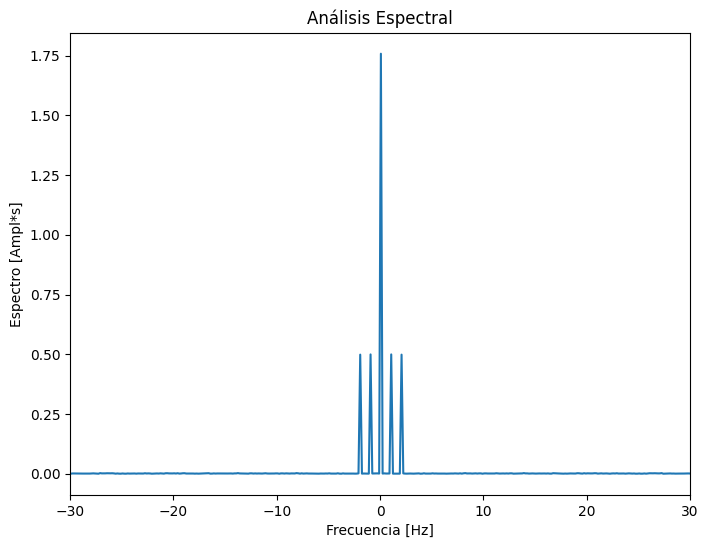

In [4]:
#1. ANÁLISIS ESPECTRAL
N_fft=len(x_wgn)
X_f=sp.fft.fftshift(sp.fft.fft(x_wgn))/N_fft
f=np.linspace(-Fs/2,Fs/2,N_fft)

#Visualización
plt.figure(figsize=[8,6])
plt.plot(f, np.abs(X_f))
plt.xlim([-30,30])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Espectro [Ampl*s]')
plt.title('Análisis Espectral')

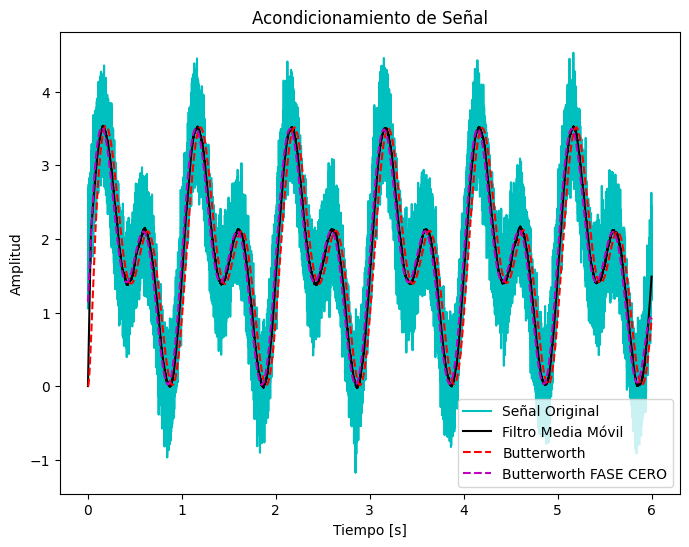

In [5]:
#2. FILTRADO DIGITAL
#Coeficientes b (x, NUMERADOR H=Y/X)
#Coeficientes a (y, DENOMINADOR H=Y/X)

#1.Filtro de Media Móvil (FIR)
N_COEFS=300
b = np.ones(N_COEFS)/N_COEFS
a=1
xf_MM=sp.signal.lfilter(b, a, x_wgn)

#2.Filtro Pasabajos Butterworth (IIR)
FCS=5 #Hz
FCS_N=FCS/(0.5*Fs)
b, a=sp.signal.butter(2, FCS_N,btype='low')
xf_BT=sp.signal.lfilter(b, a, x_wgn)

#3.Filtro Pasabajos Butterworth (IIR - FASE CERO)
#NOTA: La aplicación del filtro a izquierda y a derecha (filtfilt) posibilita EVITAR que la señal filtrada quede DESFASADA de la original
xf_BT_ff=sp.signal.filtfilt(b, a, x_wgn)

#Visualización
plt.figure(figsize=[8,6])
plt.plot(t,x_wgn,'c',t,xf_MM,'k',t,xf_BT,'r--',t,xf_BT_ff,'m--')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Acondicionamiento de Señal')
plt.legend(('Señal Original','Filtro Media Móvil','Butterworth','Butterworth FASE CERO'))

## **PROCESAMIENTO AVANZADO**

### **2. DETECCIÓN DE LATIDOS**

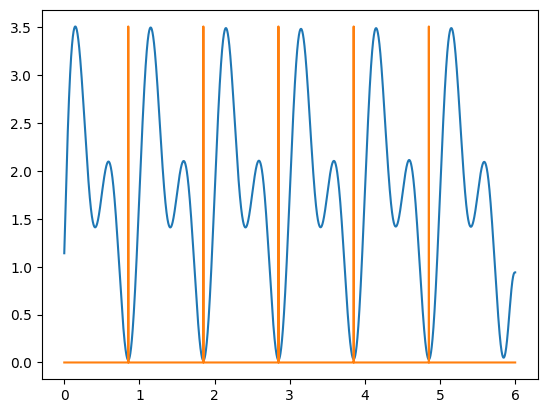

In [6]:
#Detección de latidos por método de PIE DE ONDA, Umbral 50%
x_latidos=FUN_DetLatidos(xf_BT_ff,50,4)

#Visualización
plt.plot(t,xf_BT_ff,t,x_latidos)

### **3. CÁLCULO DEL LATIDO PROMEDIO**

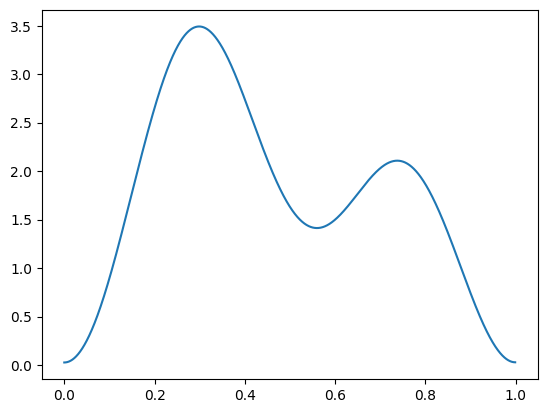

In [7]:
#Para el cálculo del latido promedio se utilizan las detectadas efectuadas anteriormente y se pasan las ubicaciones de las mismas
x_PosLat = np.where(x_latidos)[0]
#Cálculo del Latido Promedio
Lat_Prom,t_Prom=FUN_PromLatidos(xf_BT_ff, x_PosLat, t)
plt.plot(t_Prom,Lat_Prom)